# Face Recognition using CNN on the Labeled Faces in the Wild (LFW) Dataset

Recognizes/classifies a person's identity from a face image using a Convolutional Neural Network, trained on the LFW ("in the wild") dataset.

**Dataset:** Labeled Faces in the Wild (LFW), fetched automatically via `sklearn.datasets.fetch_lfw_people` (downloads once, then caches). Only people with a minimum number of images are kept, so every class has enough samples for training.

Name- Abhigyan Gaurav

Registration no: 23BCE10378


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

%matplotlib inline

## Step 1: Load the dataset

In [2]:
# min_faces_per_person filters out people with too few images, so every
# class has enough samples to train/test on.
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.5, color=False)

X = lfw_people.images            # shape: (n_samples, height, width)
y = lfw_people.target            # integer class labels
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

n_samples, h, w = X.shape
print(f"Dataset: {n_samples} images, {h}x{w} pixels, {n_classes} classes")
print("People:", list(target_names))

Dataset: 1288 images, 62x47 pixels, 7 classes
People: [np.str_('Ariel Sharon'), np.str_('Colin Powell'), np.str_('Donald Rumsfeld'), np.str_('George W Bush'), np.str_('Gerhard Schroeder'), np.str_('Hugo Chavez'), np.str_('Tony Blair')]


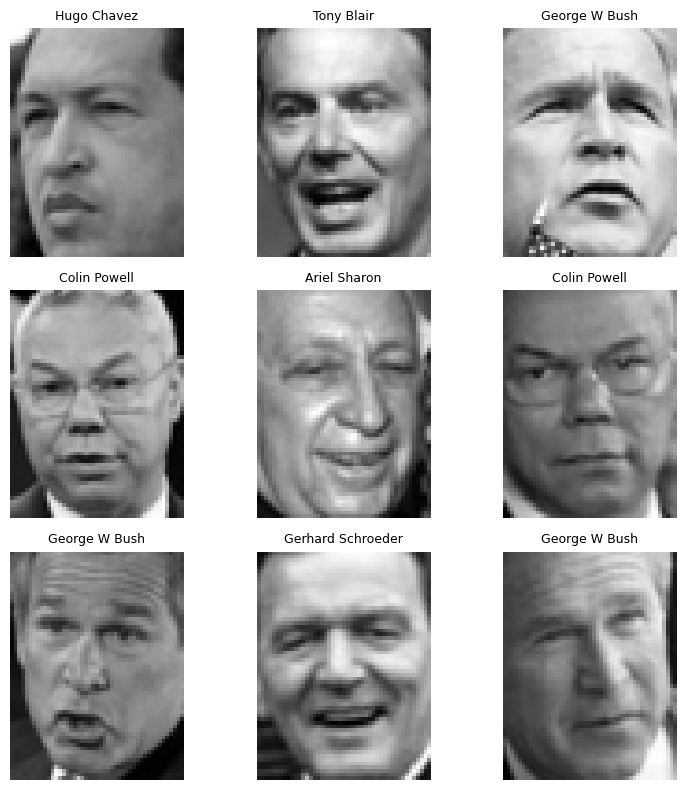

In [3]:
# Preview a few sample faces
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(target_names[y[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 2: Preprocess

In [4]:
# Normalize to [0, 1] and add a channel dimension for the CNN (grayscale)
X = X.astype("float32") / 255.0
X = np.expand_dims(X, axis=-1)   # shape: (n_samples, h, w, 1)

y_cat = to_categorical(y, num_classes=n_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

## Step 3: Build the CNN

In [5]:
model = models.Sequential([
    layers.Input(shape=(h, w, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 47, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,241,607 (4.74 MB)

 Trainable params: 1,241,607 (4.74 MB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Train

In [6]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    verbose=1,
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - accuracy: 0.3948 - loss: 1.7509 - val_accuracy: 0.4369 - val_loss: 1.6792
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4088 - loss: 1.7085 - val_accuracy: 0.4369 - val_loss: 1.6993
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4088 - loss: 1.6909 - val_accuracy: 0.4369 - val_loss: 1.6772
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4088 - loss: 1.7068 - val_accuracy: 0.4369 - val_loss: 1.6803
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4088 - loss: 1.7062 - val_accuracy: 0.4369 - val_loss: 1.6767
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4088 - loss: 1.6972 - val_accuracy: 0.4369 - val_loss: 1.6846
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4088 - loss: 1.7004 - val_accuracy: 0.4369 - val_loss: 1.6788
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4088 - loss: 1.6977 - val_accuracy: 0.4369 - val_lo

## Step 5: Evaluate

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.4109
Test Loss: 1.6829


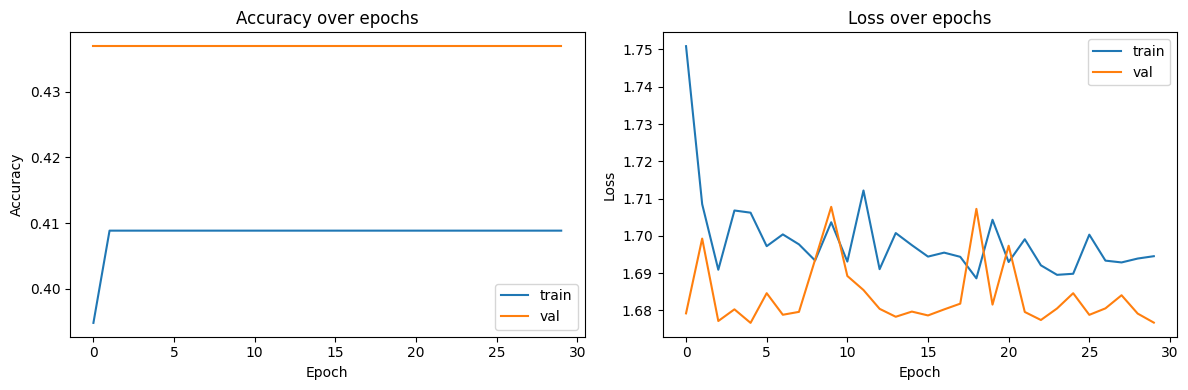

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Save the trained model

In [9]:
model.save("lfw_face_recognition_cnn.keras")
print("Model saved to lfw_face_recognition_cnn.keras")

Model saved to lfw_face_recognition_cnn.keras
